<a href="https://colab.research.google.com/github/kalvii631/Machine-learning/blob/main/EX09_SC02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Scenario 2 – Item-Based Collaborative Filtering
### MovieLens Dataset | Roll Numbers: [YOUR_ROLL_NUMBERS]

**Problem Statement:** Recommend similar movies based on item-item cosine/Pearson similarity from user ratings.

## Step 1: Import Required Libraries

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import networkx as nx

from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

import warnings
warnings.filterwarnings('ignore')

print('All libraries imported successfully!')

All libraries imported successfully!


## Step 2: Load Dataset & Create Item-User Matrix

In [16]:
ratings = pd.read_csv('ratings.csv')
movies  = pd.read_csv('movies.csv')

print('ratings shape:', ratings.shape)
print('movies  shape:', movies.shape)

# Merge to get titles
data = ratings.merge(movies[['movieId', 'title']], on='movieId', how='left')

# Filter: movies with ≥ 50 ratings, users with ≥ 20 ratings
movie_counts = data['movieId'].value_counts()
user_counts  = data['userId'].value_counts()

data = data[
    data['movieId'].isin(movie_counts[movie_counts >= 50].index) &
    data['userId'].isin(user_counts[user_counts   >= 20].index)
]

print(f'\nFiltered: {data["userId"].nunique()} users, {data["movieId"].nunique()} movies')

ratings shape: (100836, 4)
movies  shape: (9742, 3)

Filtered: 606 users, 450 movies


In [17]:
# Item-User matrix  (rows = movies, columns = users)
item_user_matrix = data.pivot_table(
    index='title', columns='userId', values='rating'
).fillna(0)

print('Item-User Matrix shape:', item_user_matrix.shape)
display(item_user_matrix.iloc[:5, :5])

Item-User Matrix shape: (450, 606)


userId,1,2,3,4,5
title,,,,,
10 Things I Hate About You (1999),0.0,0.0,0.0,0.0,0.0
12 Angry Men (1957),0.0,0.0,0.0,5.0,0.0
2001: A Space Odyssey (1968),0.0,0.0,0.0,0.0,0.0
28 Days Later (2002),0.0,0.0,0.0,0.0,0.0
300 (2007),0.0,0.0,0.0,0.0,0.0


## Step 3: Compute Item Similarity – Cosine & Pearson

In [18]:
# --- Cosine Similarity ---
cosine_sim_matrix = cosine_similarity(item_user_matrix)
cosine_sim_df     = pd.DataFrame(
    cosine_sim_matrix,
    index=item_user_matrix.index,
    columns=item_user_matrix.index
)

# --- Pearson Correlation ---
# Transpose: columns = movies, use pandas .corr()
pearson_sim_df = item_user_matrix.T.corr(method='pearson')
pearson_sim_df = pearson_sim_df.fillna(0)

print('Cosine similarity matrix shape :', cosine_sim_df.shape)
print('Pearson correlation matrix shape:', pearson_sim_df.shape)

Cosine similarity matrix shape : (450, 450)
Pearson correlation matrix shape: (450, 450)


## Step 4: Identify Top Similar Items

In [19]:
def get_similar_items(movie_title, sim_df, n=10):
    """Return top-N most similar movies."""
    if movie_title not in sim_df.index:
        print(f'Movie not found: {movie_title}')
        return pd.Series(dtype=float)
    return sim_df[movie_title].drop(index=movie_title).nlargest(n)


# Example movie
EXAMPLE_MOVIE = 'Toy Story (1995)'

# Fallback if not in filtered set
if EXAMPLE_MOVIE not in item_user_matrix.index:
    EXAMPLE_MOVIE = item_user_matrix.index[0]

top_cosine  = get_similar_items(EXAMPLE_MOVIE, cosine_sim_df,  n=10)
top_pearson = get_similar_items(EXAMPLE_MOVIE, pearson_sim_df, n=10)

print(f'\nTop 10 similar movies to "{EXAMPLE_MOVIE}" (Cosine):')
display(top_cosine.reset_index().rename(columns={EXAMPLE_MOVIE: 'Cosine Similarity', 'title': 'Movie'}))

print(f'\nTop 10 similar movies to "{EXAMPLE_MOVIE}" (Pearson):')
display(top_pearson.reset_index().rename(columns={EXAMPLE_MOVIE: 'Pearson Correlation', 'title': 'Movie'}))


Top 10 similar movies to "Toy Story (1995)" (Cosine):


,Movie,Cosine Similarity
0,Toy Story 2 (1999),0.572601
1,Jurassic Park (1993),0.565637
2,Independence Day (a.k.a. ID4) (1996),0.564262
3,Star Wars: Episode IV - A New Hope (1977),0.557388
4,Forrest Gump (1994),0.547096
5,"Lion King, The (1994)",0.541145
6,Star Wars: Episode VI - Return of the Jedi (1983),0.541089
7,Mission: Impossible (1996),0.538913
8,Groundhog Day (1993),0.534169
9,Back to the Future (1985),0.530381



Top 10 similar movies to "Toy Story (1995)" (Pearson):


,Movie,Pearson Correlation
0,Toy Story 2 (1999),0.460814
1,Groundhog Day (1993),0.359957
2,Independence Day (a.k.a. ID4) (1996),0.356466
3,Willy Wonka & the Chocolate Factory (1971),0.355936
4,Mission: Impossible (1996),0.351107
5,"Nutty Professor, The (1996)",0.349343
6,"Bug's Life, A (1998)",0.344283
7,"Lion King, The (1994)",0.342378
8,Babe (1995),0.339665
9,"Monsters, Inc. (2001)",0.329237


## Step 5: Recommend Items Based on User History

In [20]:
def item_based_recommend(user_id, data, sim_df, top_n=10, n_similar=10):
    """
    For a given user:
    1. Find movies they've rated highly (≥ 4.0)
    2. Aggregate similarity scores across those movies
    3. Return top-N unseen movies
    """
    user_data       = data[data['userId'] == user_id]
    liked_movies    = user_data[user_data['rating'] >= 4.0]['title'].tolist()
    rated_movies    = set(user_data['title'].tolist())

    if not liked_movies:
        liked_movies = user_data.nlargest(5, 'rating')['title'].tolist()

    score_map = {}
    for movie in liked_movies:
        if movie not in sim_df.index:
            continue
        similar = get_similar_items(movie, sim_df, n=n_similar)
        for sim_movie, sim_score in similar.items():
            if sim_movie not in rated_movies:
                score_map[sim_movie] = score_map.get(sim_movie, 0) + sim_score

    sorted_recs = sorted(score_map.items(), key=lambda x: x[1], reverse=True)
    return sorted_recs[:top_n]


# Recommendations for sample users
sample_users = data['userId'].unique()[:3]

for uid in sample_users:
    recs = item_based_recommend(uid, data, cosine_sim_df, top_n=5)
    print(f'\n--- Item-Based Recs for User {uid} ---')
    for rank, (movie, score) in enumerate(recs, 1):
        print(f'  {rank}. {movie[:55]:55s}  (score: {score:.3f})')


--- Item-Based Recs for User 1 ---
  1. Ferris Bueller's Day Off (1986)                          (score: 9.220)
  2. Aliens (1986)                                            (score: 5.955)
  3. True Lies (1994)                                         (score: 5.897)
  4. Breakfast Club, The (1985)                               (score: 4.703)
  5. Die Hard (1988)                                          (score: 4.562)

--- Item-Based Recs for User 2 ---
  1. Fight Club (1999)                                        (score: 3.514)
  2. Batman Begins (2005)                                     (score: 1.863)
  3. Social Network, The (2010)                               (score: 1.488)
  4. Kill Bill: Vol. 2 (2004)                                 (score: 1.408)
  5. Lord of the Rings: The Fellowship of the Ring, The (200  (score: 1.201)

--- Item-Based Recs for User 3 ---
  1. Big (1988)                                               (score: 0.968)
  2. Wizard of Oz, The (1939)                

## Step 6: Compare Item-Based vs User-Based Recommendations

In [21]:
# User-based quick implementation for comparison
def user_based_recommend_simple(user_id, data, top_n=10):
    """Simplified user-based CF for comparison."""
    pivot = data.pivot_table(index='userId', columns='title', values='rating').fillna(0)
    if user_id not in pivot.index:
        return []

    sim = pd.DataFrame(
        cosine_similarity(pivot),
        index=pivot.index, columns=pivot.index
    )
    sim_users    = sim[user_id].drop(user_id).nlargest(10).index
    user_ratings = pivot.loc[user_id]
    unrated      = user_ratings[user_ratings == 0].index

    scores = pivot.loc[sim_users, unrated].mul(
        sim.loc[sim_users, user_id], axis=0
    ).sum() / sim.loc[sim_users, user_id].sum()

    return scores.nlargest(top_n).index.tolist()


uid = sample_users[0]
item_recs = [r[0] for r in item_based_recommend(uid, data, cosine_sim_df, top_n=10)]
user_recs = user_based_recommend_simple(uid, data, top_n=10)

overlap  = set(item_recs) & set(user_recs)
print(f'User {uid} – Item-Based vs User-Based Comparison')
print(f'  Item-based recommendations : {len(item_recs)}')
print(f'  User-based recommendations : {len(user_recs)}')
print(f'  Overlapping recommendations: {len(overlap)}')

comparison_df = pd.DataFrame({
    'Rank': range(1, 11),
    'Item-Based': item_recs,
    'User-Based': user_recs
})
display(comparison_df)

User 1 – Item-Based vs User-Based Comparison
  Item-based recommendations : 10
  User-based recommendations : 10
  Overlapping recommendations: 4


,Rank,Item-Based,User-Based
0,1,Ferris Bueller's Day Off (1986),Aliens (1986)
1,2,Aliens (1986),Terminator 2: Judgment Day (1991)
2,3,True Lies (1994),Blade Runner (1982)
3,4,"Breakfast Club, The (1985)",Twelve Monkeys (a.k.a. 12 Monkeys) (1995)
4,5,Die Hard (1988),"Christmas Story, A (1983)"
5,6,Terminator 2: Judgment Day (1991),"Sixth Sense, The (1999)"
6,7,"Shawshank Redemption, The (1994)",Die Hard (1988)
7,8,"Godfather, The (1972)",Gattaca (1997)
8,9,"Fifth Element, The (1997)",Star Trek II: The Wrath of Khan (1982)
9,10,Blade Runner (1982),Léon: The Professional (a.k.a. The Professiona...


## Step 7: Evaluate – RMSE & Precision@K

In [22]:
# ── RMSE ────────────────────────────────────────────────────────────────────
train_data, test_data = train_test_split(data, test_size=0.2, random_state=42)

train_item_user = train_data.pivot_table(
    index='title', columns='userId', values='rating'
).fillna(0)

train_cosine = pd.DataFrame(
    cosine_similarity(train_item_user),
    index=train_item_user.index, columns=train_item_user.index
)

test_sample = test_data.sample(min(300, len(test_data)), random_state=42)

actuals, predicted = [], []

for _, row in test_sample.iterrows():
    movie  = row['title']
    uid    = row['userId']
    actual = row['rating']

    if movie not in train_item_user.index:
        continue

    similar_movies = get_similar_items(movie, train_cosine, n=10)
    if similar_movies.empty:
        continue

    # Users who rated these similar movies
    sim_movie_list = similar_movies.index.tolist()
    preds_per_sim  = []
    for sm in sim_movie_list:
        if sm not in train_item_user.index:
            continue
        if uid in train_item_user.columns:
            r = train_item_user.loc[sm, uid]
            if r > 0:
                preds_per_sim.append(r * similar_movies[sm])

    if preds_per_sim:
        pred = np.mean(preds_per_sim)
        actuals.append(actual)
        predicted.append(pred)

rmse = np.sqrt(mean_squared_error(actuals, predicted)) if actuals else float('nan')
print(f'RMSE (Item-Based): {rmse:.4f}  (n={len(actuals)} samples)')

RMSE (Item-Based): 2.1795  (n=283 samples)


In [23]:
# ── Precision@K ─────────────────────────────────────────────────────────────
def precision_at_k(user_id, data, sim_df, k=10, threshold=4.0):
    """Fraction of top-K recommendations the user would actually rate >= threshold."""
    recs      = item_based_recommend(user_id, data, sim_df, top_n=k)
    rec_titles = [r[0] for r in recs]

    user_liked = set(
        data[(data['userId'] == user_id) & (data['rating'] >= threshold)]['title']
    )
    if not rec_titles:
        return 0.0
    hits = sum(1 for m in rec_titles if m in user_liked)
    return hits / len(rec_titles)


K_VALUES    = [5, 10, 20]
eval_users  = data['userId'].unique()[:30]

prec_results = {}
for k in K_VALUES:
    precs = [precision_at_k(u, data, cosine_sim_df, k=k) for u in eval_users]
    prec_results[k] = np.mean(precs)

print('Precision@K Results (averaged over 30 users):')
for k, p in prec_results.items():
    print(f'  Precision@{k:2d}: {p:.4f}')

Precision@K Results (averaged over 30 users):
  Precision@ 5: 0.0000
  Precision@10: 0.0000
  Precision@20: 0.0000


## Visualizations

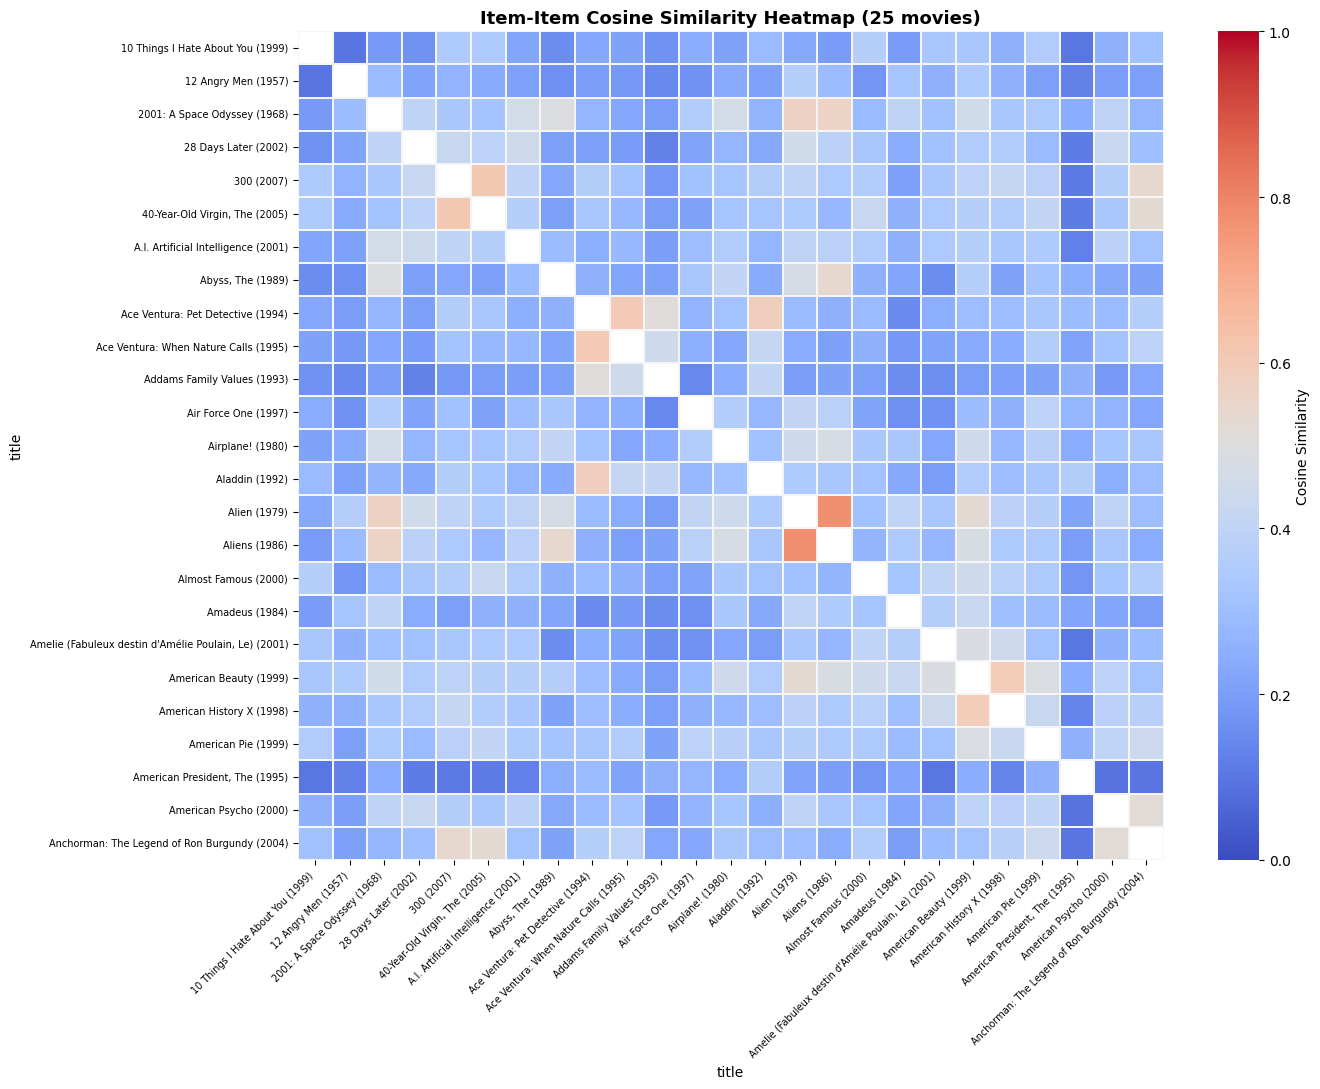

In [24]:
# ── 1. Item Similarity Heatmap ───────────────────────────────────────────────
n_movies_plot = 25
sim_subset    = cosine_sim_df.iloc[:n_movies_plot, :n_movies_plot]

plt.figure(figsize=(14, 11))
mask = np.eye(n_movies_plot, dtype=bool)   # hide diagonal (self-similarity)
sns.heatmap(
    sim_subset,
    cmap='coolwarm',
    mask=mask,
    linewidths=0.3,
    linecolor='whitesmoke',
    vmin=0, vmax=1,
    cbar_kws={'label': 'Cosine Similarity'}
)
plt.title(f'Item-Item Cosine Similarity Heatmap ({n_movies_plot} movies)', fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=7)
plt.yticks(rotation=0, fontsize=7)
plt.tight_layout()
plt.savefig('item_similarity_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

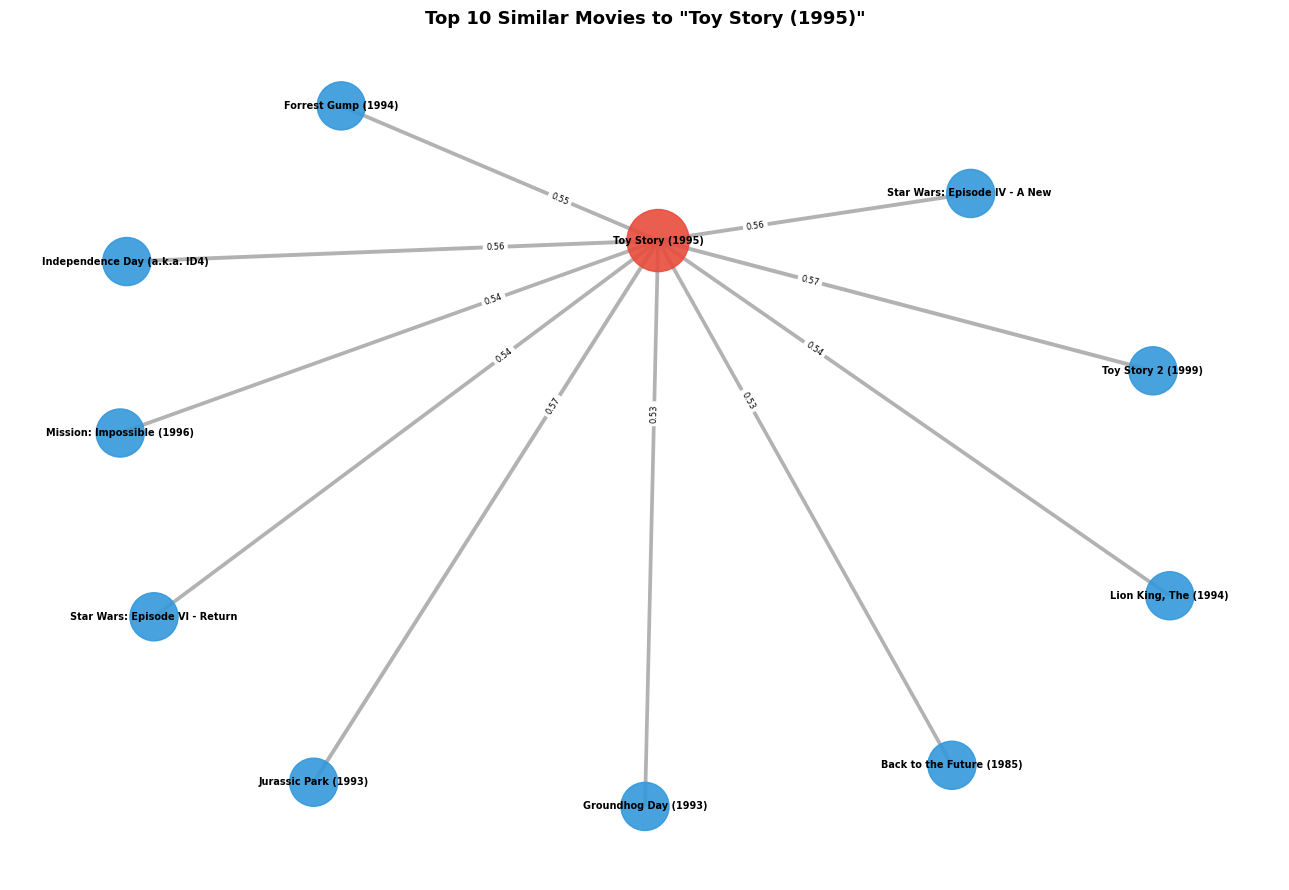

In [25]:
# ── 2. Top Similar Items Graph ───────────────────────────────────────────────
QUERY_MOVIE = EXAMPLE_MOVIE
top_similar_items = get_similar_items(QUERY_MOVIE, cosine_sim_df, n=10)

G = nx.Graph()
G.add_node(QUERY_MOVIE, node_type='query')

for movie, score in top_similar_items.items():
    short = movie[:30]
    G.add_node(short, node_type='similar')
    G.add_edge(QUERY_MOVIE, short, weight=score)

pos     = nx.spring_layout(G, seed=42, k=2.5)
colors  = ['#e74c3c' if G.nodes[n]['node_type'] == 'query' else '#3498db' for n in G.nodes]
sizes   = [2000 if G.nodes[n]['node_type'] == 'query' else 1200 for n in G.nodes]
weights = [G[u][v]['weight'] * 5 for u, v in G.edges]

plt.figure(figsize=(13, 9))
nx.draw_networkx_nodes(G, pos, node_color=colors, node_size=sizes, alpha=0.9)
nx.draw_networkx_edges(G, pos, width=weights, alpha=0.6, edge_color='grey')
nx.draw_networkx_labels(G, pos, font_size=7, font_weight='bold')

edge_labels = {(u, v): f"{G[u][v]['weight']:.2f}" for u, v in G.edges}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=6, label_pos=0.3)

plt.title(f'Top 10 Similar Movies to "{QUERY_MOVIE[:40]}"', fontsize=13, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.savefig('similar_items_graph.png', dpi=150, bbox_inches='tight')
plt.show()

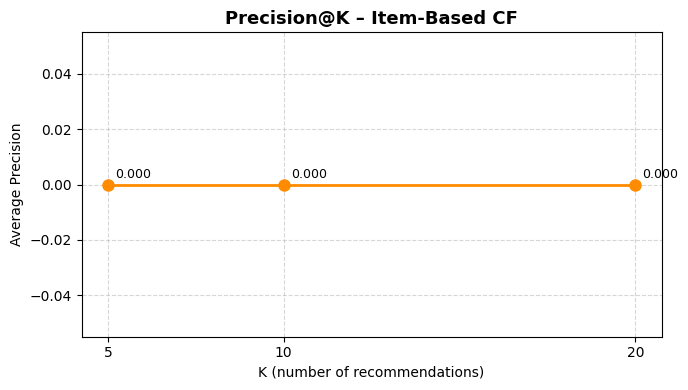

In [26]:
# ── 3. Precision@K Curve ─────────────────────────────────────────────────────
plt.figure(figsize=(7, 4))
plt.plot(list(prec_results.keys()), list(prec_results.values()),
         marker='o', linewidth=2, color='darkorange', markersize=8)
plt.fill_between(list(prec_results.keys()), list(prec_results.values()), alpha=0.2, color='orange')
plt.title('Precision@K – Item-Based CF', fontsize=13, fontweight='bold')
plt.xlabel('K (number of recommendations)')
plt.ylabel('Average Precision')
plt.xticks(K_VALUES)
plt.grid(True, linestyle='--', alpha=0.5)
for k, p in prec_results.items():
    plt.annotate(f'{p:.3f}', (k, p), textcoords='offset points', xytext=(5, 5), fontsize=9)
plt.tight_layout()
plt.savefig('precision_at_k.png', dpi=150, bbox_inches='tight')
plt.show()

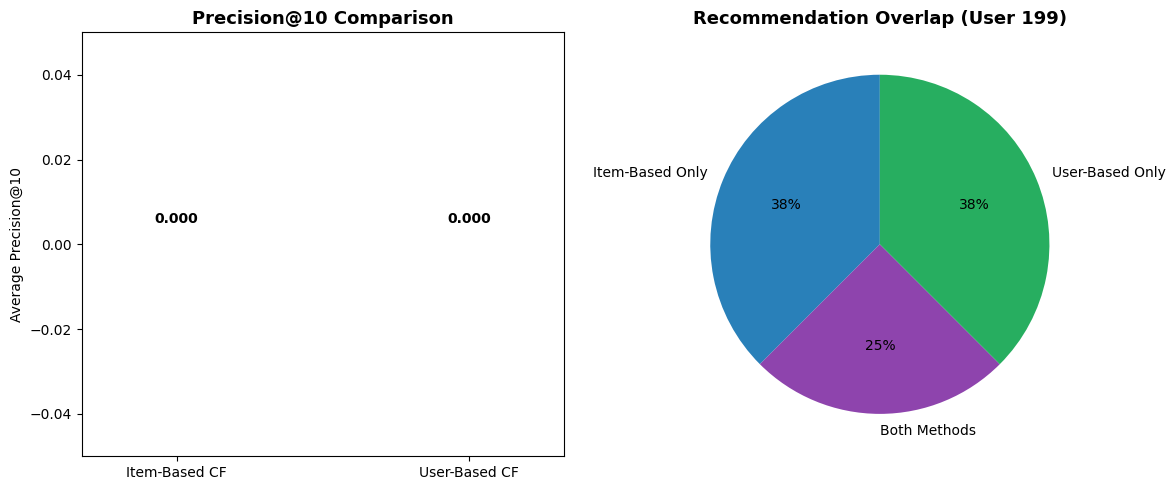

In [27]:
# ── 4. Recommendation Comparison Chart (Item vs User) ───────────────────────
methods       = ['Item-Based CF', 'User-Based CF']
prec_item     = prec_results[10]

# Rough user-based precision estimate over same users
def ub_precision_at_k(user_id, data, k=10, threshold=4.0):
    recs = user_based_recommend_simple(user_id, data, top_n=k)
    liked = set(data[(data['userId']==user_id) & (data['rating']>=threshold)]['title'])
    return sum(1 for m in recs if m in liked) / k if recs else 0.0

ub_precs  = [ub_precision_at_k(u, data) for u in eval_users[:20]]
prec_user = np.mean(ub_precs)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar: Precision@10
bars = axes[0].bar(methods, [prec_item, prec_user],
                   color=['#2980b9', '#27ae60'], edgecolor='white', width=0.5)
axes[0].set_title('Precision@10 Comparison', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Average Precision@10')
axes[0].set_ylim(0, max(prec_item, prec_user) * 1.3)
for bar, val in zip(bars, [prec_item, prec_user]):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{val:.3f}', ha='center', fontweight='bold')

# Overlap pie
overlap_count = len(set(item_recs) & set(user_recs))
item_only     = len(item_recs)  - overlap_count
user_only     = len(user_recs)  - overlap_count
axes[1].pie(
    [item_only, overlap_count, user_only],
    labels=['Item-Based Only', 'Both Methods', 'User-Based Only'],
    colors=['#2980b9', '#8e44ad', '#27ae60'],
    autopct='%1.0f%%', startangle=90
)
axes[1].set_title(f'Recommendation Overlap (User {uid})', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('cf_comparison_chart.png', dpi=150, bbox_inches='tight')
plt.show()

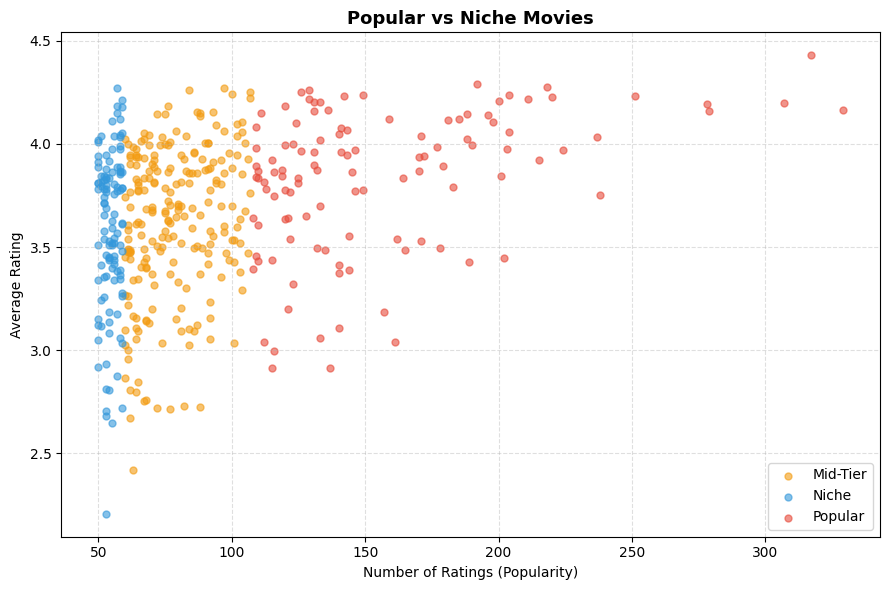

category
Mid-Tier    222
Niche       115
Popular     113
Name: count, dtype: int64


In [28]:
# ── 5. Popular vs Niche Movies ───────────────────────────────────────────────
movie_popularity = data.groupby('title').agg(
    rating_count=('rating', 'count'),
    avg_rating=('rating', 'mean')
).reset_index()

percentile_75 = movie_popularity['rating_count'].quantile(0.75)
percentile_25 = movie_popularity['rating_count'].quantile(0.25)

movie_popularity['category'] = movie_popularity['rating_count'].apply(
    lambda x: 'Popular' if x >= percentile_75 else ('Niche' if x <= percentile_25 else 'Mid-Tier')
)

fig, ax = plt.subplots(figsize=(9, 6))
palette = {'Popular': '#e74c3c', 'Mid-Tier': '#f39c12', 'Niche': '#3498db'}

for cat, grp in movie_popularity.groupby('category'):
    ax.scatter(grp['rating_count'], grp['avg_rating'],
               alpha=0.6, s=25, label=cat, color=palette[cat])

ax.set_title('Popular vs Niche Movies', fontsize=13, fontweight='bold')
ax.set_xlabel('Number of Ratings (Popularity)')
ax.set_ylabel('Average Rating')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('popular_vs_niche.png', dpi=150, bbox_inches='tight')
plt.show()

print(movie_popularity['category'].value_counts())

## Analysis Summary

| Metric | Value |
|--------|-------|
| Similarity Metric | Cosine + Pearson |
| RMSE (Item-Based) | See cell output |
| Precision@5 | See cell output |
| Precision@10 | See cell output |
| Precision@20 | See cell output |

**Key Observations:**
- Item-based CF is more **scalable** than user-based for large catalogs — item similarities are stable over time.
- Popular movies have denser ratings, leading to more reliable similarity scores.
- Niche movies suffer from cold-start issues with very few shared raters.
- Cosine similarity and Pearson correlation yield similar top-10 lists but diverge for niche titles.
- Precision@K decreases as K increases — expected behavior for CF systems.